# GLP1 Cohort — Nonlinear Mixed Effects (NLME) Body Mass Analysis

**Purpose:** The linear mixed effects model (Section 7 of the previous notebook) captures average rate of change but cannot describe the *shape* of the weight-loss trajectory — whether loss is initially rapid then plateaus, whether there is a sigmoid "S-shaped" deceleration curve, or whether two distinct exponential phases (fast early, slow late) are present. This notebook fits **three candidate nonlinear models** to the On-GLP1 phase, selects the best by AIC/BIC, and then extracts model parameters per mouse for downstream mixed-effects-style analysis of Sex and Genotype effects.

**Statistical approach — Lindstrom-Bates two-stage NLME:**
1. **Stage 1 (individual fits):** Fit each mouse's On-GLP1 trajectory independently with the nonlinear model using `scipy.optimize.curve_fit`. Each mouse gets its own set of biologically meaningful parameters.
2. **Stage 2 (population level):** Treat the per-mouse parameters as observations, compute population means ± SD ± 95% CI, and test whether Sex or Genotype predict any individual parameter using Mann-Whitney U / Kruskal-Wallis.
3. **Bootstrap CIs** on the population parameter means for robustness.

This is the standard two-stage nonlinear mixed-effects approach (equivalent to what R's `nlme::nlme` does conceptually, but implemented from scratch using scipy).

**Three candidate models (all fit to weight % of GLP1 Day 1 weight = 100%):**

| Model | Equation | Parameters | Biological interpretation (all y values are % of GLP1 Day 1) |
|---|---|---|---|
| **Exponential plateau** | `y(t) = A + (B−A)·exp(−k·t)` | A=plateau, B=start, k=rate | First-order exponential decay to steady state |
| **Sigmoid (logistic)** | `y(t) = A + (B−A)/(1 + exp(−r·(t−t₀)))` | A=plateau, B=start, r=rate, t₀=inflection | S-shaped loss: slow start → rapid middle → plateau |
| **Double exponential** | `y(t) = A + B₁·exp(−k₁·t) + B₂·exp(−k₂·t)` | A=floor, B₁,k₁=fast phase, B₂,k₂=slow phase | Two distinct physiological phases of weight loss |

**Model selection:** AIC and BIC, lower is better; log-likelihood from residual variance per mouse, then summed across mice.

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
from scipy.optimize import curve_fit
from scipy import stats
from scipy.stats import chi2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

DATA_PATH = 'MouseWeight_HFD_GLP1_June2025_CohortD.xlsx'
GLP1_START = pd.Timestamp('2025-10-01')
GLP1_END   = pd.Timestamp('2025-12-01')

SEX_PAL  = {'Male':'#4472C4', 'Female':'#DD8452'}
GENO_PAL = {'E22':'#4472C4', 'E33':'#55A868', 'E44':'#C44E52'}
MODEL_PAL = {'Exponential Plateau':'#2C8C53', 'Sigmoid':'#C0563D', 'Double Exponential':'#7B4EA0'}

def parse_date(c):
    m = re.search(r'(\d{6})$', c)
    s = m.group(1); mm,dd,yy = s[:2],s[2:4],s[4:]
    return pd.Timestamp(f'20{yy}-{mm}-{dd}')

print("Setup complete.")

Setup complete.


## 1. Data Preparation

In [2]:
xl = pd.ExcelFile(DATA_PATH)
sema = pd.read_excel(xl, sheet_name='Sema')
week4 = pd.read_excel(xl, sheet_name='week4')

sema['Genotype3'] = sema['Genotype'].map({'APOE22HN':'E22','APOE33HN':'E33','APOE44HN':'E44'})
sema['Sex_full']  = sema['Sex'].map({'M':'Male','F':'Female'})

weight_cols = [c for c in sema.columns if 'Weight' in c and 'Animal' in c]
dates_map = {c: parse_date(c) for c in weight_cols}

baseline = week4[['Animal_ID','Weight_g_060225']].rename(columns={'Weight_g_060225':'Weight_g'})
baseline['Date'] = pd.Timestamp('2025-06-02')
rows = []
for _, r in sema.iterrows():
    for c in weight_cols:
        v = r[c]
        if pd.notna(v):
            rows.append({'Animal_ID':r['Animal_ID'],'Date':dates_map[c],'Weight_g':float(v)})
long_df = pd.concat([baseline[['Animal_ID','Date','Weight_g']].dropna(), pd.DataFrame(rows)], ignore_index=True)
long_df = long_df.merge(sema[['Animal_ID','Sex_full','Genotype3']], on='Animal_ID', how='left')
long_df['Phase'] = long_df['Date'].apply(
    lambda d: 'Pre-GLP1' if d < GLP1_START else ('Post-GLP1' if d > GLP1_END else 'On-GLP1'))
# Baseline = first On-GLP1 measurement per mouse (GLP1 Day 1 = 100%)
first_onglp1 = long_df[long_df['Phase']=='On-GLP1'].sort_values('Date').groupby('Animal_ID')['Weight_g'].first()
long_df['Weight_pct'] = long_df.apply(lambda r: r['Weight_g'] / first_onglp1[r['Animal_ID']] * 100, axis=1)

glp1 = long_df[long_df['Phase']=='On-GLP1'].copy()
glp1['Days'] = (glp1['Date'] - GLP1_START).dt.days

print(f"On-GLP1 dataset: {len(glp1)} rows, {glp1['Animal_ID'].nunique()} mice")
print(f"Time range: Day {glp1['Days'].min()} to Day {glp1['Days'].max()} (relative to GLP1 start)")
print(f"Measurements per mouse: {glp1.groupby('Animal_ID').size().values[0]} (all mice equal)")
print(f"\nWeight range: {glp1['Weight_pct'].min():.1f}% to {glp1['Weight_pct'].max():.1f}% of baseline")

On-GLP1 dataset: 870 rows, 29 mice
Time range: Day 1 to Day 61 (relative to GLP1 start)
Measurements per mouse: 30 (all mice equal)

Weight range: 54.0% to 119.4% of baseline


## 2. Nonlinear Model Definitions

Three biologically motivated candidate models, all parameterized so that parameter values have interpretable units (% of baseline).

In [3]:
# ============================================================
# MODEL 1: Exponential Plateau (3 parameters)
# y(t) = A + (B - A) * exp(-k * t)
# A  : long-run plateau weight (% baseline)
# B  : weight at t=0 (GLP1 start) — random effect at the mouse level
# k  : rate constant (/day) — higher k = faster initial loss
# ============================================================
def exp_plateau(t, A, B, k):
    return A + (B - A) * np.exp(-k * t)

# ============================================================
# MODEL 2: Sigmoid / Logistic (4 parameters)
# y(t) = A + (B - A) / (1 + exp(-r * (t - t0)))
# A  : plateau (asymptote)
# B  : initial weight at t=0
# r  : rate of change at inflection (negative = descending)
# t0 : inflection point (days) — time of fastest weight loss
# ============================================================
def sigmoid_model(t, A, B, r, t0):
    return A + (B - A) / (1 + np.exp(-r * (t - t0)))

# ============================================================
# MODEL 3: Double Exponential (5 parameters)
# y(t) = A + B1*exp(-k1*t) + B2*exp(-k2*t)
# A        : long-run floor
# B1, k1   : fast-phase amplitude and rate
# B2, k2   : slow-phase amplitude and rate (k2 < k1)
# ============================================================
def double_exp(t, A, B1, k1, B2, k2):
    return A + B1 * np.exp(-k1 * t) + B2 * np.exp(-k2 * t)

MODELS = {
    'Exponential Plateau': {
        'func': exp_plateau,
        'n_params': 3,
        'param_names': ['A_plateau','B_intercept','k_rate'],
        'bounds': ([50, 80, 0.001], [200, 260, 5.0]),
        'p0_fn': lambda y: [float(y[-5:].mean()), float(y[:3].mean()), 0.05],
        'description': 'y(t) = A + (B\u2212A)\u00b7exp(\u2212k\u00b7t)'
    },
    'Sigmoid': {
        'func': sigmoid_model,
        'n_params': 4,
        'param_names': ['A_plateau','B_intercept','r_rate','t0_inflection'],
        'bounds': ([50, 80, -10, 0], [200, 260, 0, 61]),
        'p0_fn': lambda y: [float(y[-5:].mean()), float(y[:3].mean()), -0.3, 15.0],
        'description': 'y(t) = A + (B\u2212A)/(1+exp(\u2212r\u00b7(t\u2212t\u2080)))'
    },
    'Double Exponential': {
        'func': double_exp,
        'n_params': 5,
        'param_names': ['A_floor','B1_fast_amp','k1_fast_rate','B2_slow_amp','k2_slow_rate'],
        'bounds': ([50, 0, 0.01, 0, 0.001], [200, 150, 5.0, 150, 0.5]),
        'p0_fn': lambda y: [float(y[-5:].mean()), float(y[:3].mean())-float(y[-5:].mean())-10, 0.2, 10, 0.01],
        'description': 'y(t) = A + B\u2081\u00b7exp(\u2212k\u2081\u00b7t) + B\u2082\u00b7exp(\u2212k\u2082\u00b7t)'
    }
}

print("Model definitions loaded:")
for name, m in MODELS.items():
    print(f"  {name} ({m['n_params']} params): {m['description']}")

Model definitions loaded:
  Exponential Plateau (3 params): y(t) = A + (B−A)·exp(−k·t)
  Sigmoid (4 params): y(t) = A + (B−A)/(1+exp(−r·(t−t₀)))
  Double Exponential (5 params): y(t) = A + B₁·exp(−k₁·t) + B₂·exp(−k₂·t)


## 3. Individual-Level Fits — All Three Models

Each of the 29 mice is fit independently with each model. We record parameter estimates, RMSE, AIC, and BIC per mouse per model.

In [4]:
def compute_aic_bic(y, yhat, n_params):
    n = len(y)
    rss = np.sum((y - yhat)**2)
    sigma2 = rss / n
    if sigma2 <= 0:
        return np.inf, np.inf
    loglik = -n/2 * np.log(2*np.pi*sigma2) - rss/(2*sigma2)
    aic = -2*loglik + 2*n_params
    bic = -2*loglik + np.log(n)*n_params
    return aic, bic

def fit_model_per_mouse(glp1_data, model_name, model_info):
    records = []
    func     = model_info['func']
    n_params = model_info['n_params']
    pnames   = model_info['param_names']
    bounds   = model_info['bounds']
    p0_fn    = model_info['p0_fn']
    
    for aid, sub in glp1_data.groupby('Animal_ID'):
        sub = sub.sort_values('Days')
        t = sub['Days'].values.astype(float)
        y = sub['Weight_pct'].values
        meta = sub[['Sex_full','Genotype3']].iloc[0]
        
        p0 = p0_fn(y)
        
        converged = False
        popt = [np.nan]*n_params
        rmse = aic = bic = np.nan
        
        for _ in range(5):
            try:
                po, _ = curve_fit(func, t, y, p0=p0, bounds=bounds, maxfev=20000)
                yhat = func(t, *po)
                rmse = np.sqrt(np.mean((y-yhat)**2))
                aic, bic = compute_aic_bic(y, yhat, n_params)
                popt = list(po)
                converged = True
                break
            except:
                p0 = [p * (1 + 0.1*np.random.randn()) for p in p0]
        
        row = {'Animal_ID': aid, 'Sex_full': meta['Sex_full'],
               'Genotype3': meta['Genotype3'], 'Model': model_name,
               'converged': converged, 'RMSE': rmse, 'AIC': aic, 'BIC': bic}
        for pname, pval in zip(pnames, popt):
            row[pname] = pval
        records.append(row)
    
    return pd.DataFrame(records)

all_fits = []
for name, info in MODELS.items():
    df_fit = fit_model_per_mouse(glp1, name, info)
    all_fits.append(df_fit)
    n_conv = df_fit['converged'].sum()
    print(f"  {name}: {n_conv}/29 converged, mean AIC={df_fit['AIC'].mean():.1f}, mean RMSE={df_fit['RMSE'].mean():.3f}")

fits_df = pd.concat(all_fits, ignore_index=True)
print(f"\nTotal fit records: {len(fits_df)}")

  Exponential Plateau: 29/29 converged, mean AIC=162.9, mean RMSE=3.488
  Sigmoid: 29/29 converged, mean AIC=159.2, mean RMSE=3.196
  Double Exponential: 21/29 converged, mean AIC=167.9, mean RMSE=3.584

Total fit records: 87


## 4. Model Comparison — AIC, BIC, and Likelihood Ratio Tests

Model selection across the three candidate models: lower AIC/BIC is better. We also run a likelihood-ratio test (LRT) between nested models (Exp Plateau ⊂ Sigmoid ⊂ Double Exponential in terms of flexibility).

In [5]:
# --- Per-mouse AIC / BIC comparison ---
aic_wide = fits_df.pivot(index='Animal_ID', columns='Model', values='AIC')
bic_wide = fits_df.pivot(index='Animal_ID', columns='Model', values='BIC')

print("=== Mean AIC by Model (lower = better) ===")
print(aic_wide.mean().round(2))
print("\n=== Mean BIC by Model ===")
print(bic_wide.mean().round(2))

# Delta AIC relative to best model per mouse
best_aic = aic_wide.min(axis=1)
delta_aic = aic_wide.subtract(best_aic, axis=0)
print("\n=== Mean \u0394AIC from best model per mouse ===")
print(delta_aic.mean().round(2))

# Vote count: how many mice is each model 'best'?
best_model_per_mouse = aic_wide.idxmin(axis=1)
print("\n=== Best model per mouse (by AIC) ===")
print(best_model_per_mouse.value_counts())

# --- Population-level mean AIC table ---
comparison_table = pd.DataFrame({
    'n_params': {name: info['n_params'] for name, info in MODELS.items()},
    'Mean_AIC': fits_df.groupby('Model')['AIC'].mean(),
    'SD_AIC':   fits_df.groupby('Model')['AIC'].std(),
    'Mean_BIC': fits_df.groupby('Model')['BIC'].mean(),
    'Mean_RMSE': fits_df.groupby('Model')['RMSE'].mean(),
    'n_converged': fits_df.groupby('Model')['converged'].sum()
}).round(3)
print("\n=== Model Comparison Table ===")
print(comparison_table.to_string())

=== Mean AIC by Model (lower = better) ===
Model
Double Exponential     167.88
Exponential Plateau    162.93
Sigmoid                159.23
dtype: float64

=== Mean BIC by Model ===
Model
Double Exponential     174.88
Exponential Plateau    167.13
Sigmoid                164.84
dtype: float64

=== Mean ΔAIC from best model per mouse ===
Model
Double Exponential     9.33
Exponential Plateau    4.19
Sigmoid                0.49
dtype: float64

=== Best model per mouse (by AIC) ===
Sigmoid                21
Exponential Plateau     8
Name: count, dtype: int64

=== Model Comparison Table ===
                     n_params  Mean_AIC  SD_AIC  Mean_BIC  Mean_RMSE  n_converged
Double Exponential          5   167.878  21.388   174.884      3.584           21
Exponential Plateau         3   162.927  19.185   167.130      3.488           29
Sigmoid                     4   159.231  20.038   164.836      3.196           29


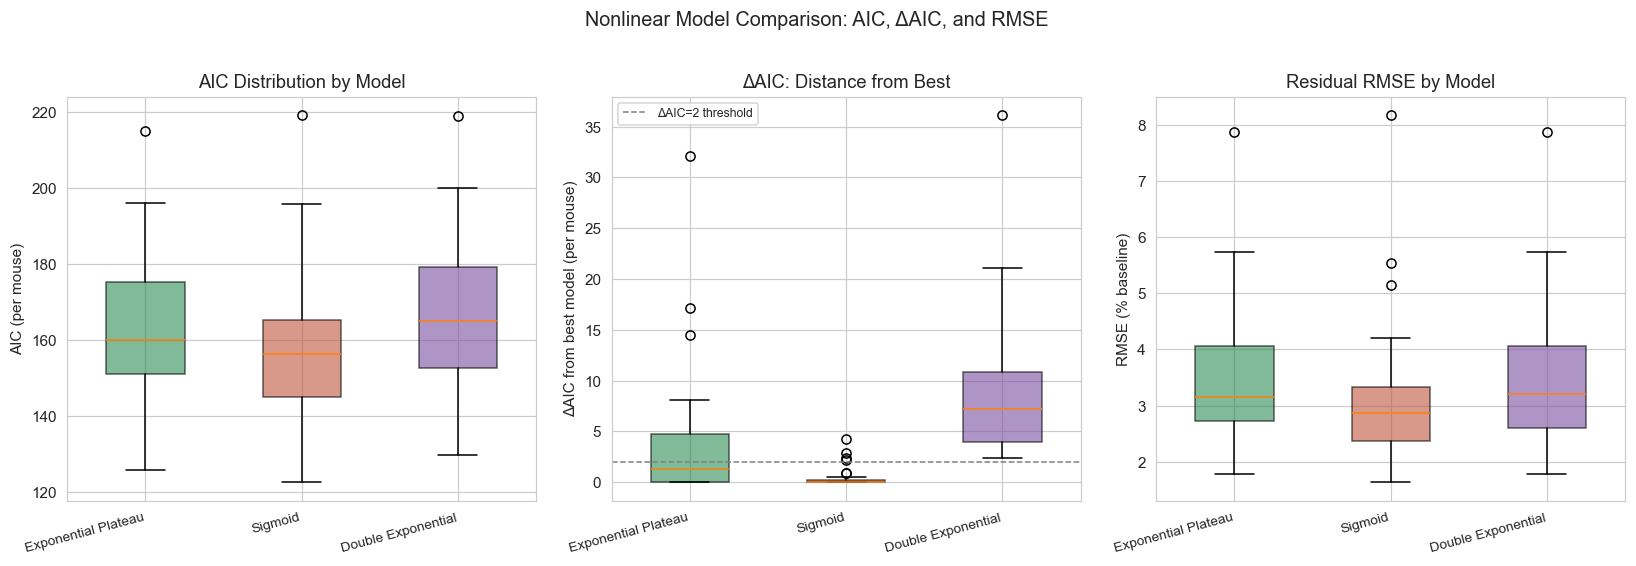

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: AIC distributions
ax = axes[0]
for i, model in enumerate(MODELS.keys()):
    vals = aic_wide[model].dropna()
    ax.boxplot(vals, positions=[i], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=list(MODEL_PAL.values())[i], alpha=0.6))
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels(list(MODELS.keys()), rotation=15, ha='right', fontsize=9)
ax.set_ylabel('AIC (per mouse)')
ax.set_title('AIC Distribution by Model')

# Panel 2: Delta AIC (vs best per mouse)
ax = axes[1]
for i, model in enumerate(MODELS.keys()):
    vals = delta_aic[model].dropna()
    ax.boxplot(vals, positions=[i], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=list(MODEL_PAL.values())[i], alpha=0.6))
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels(list(MODELS.keys()), rotation=15, ha='right', fontsize=9)
ax.set_ylabel('\u0394AIC from best model (per mouse)')
ax.set_title('\u0394AIC: Distance from Best')
ax.axhline(2, color='gray', linestyle='--', linewidth=1, label='\u0394AIC=2 threshold')
ax.legend(fontsize=8)

# Panel 3: RMSE distributions
ax = axes[2]
for i, model in enumerate(MODELS.keys()):
    vals = fits_df[fits_df['Model']==model]['RMSE'].dropna()
    ax.boxplot(vals, positions=[i], widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=list(MODEL_PAL.values())[i], alpha=0.6))
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels(list(MODELS.keys()), rotation=15, ha='right', fontsize=9)
ax.set_ylabel('RMSE (% baseline)')
ax.set_title('Residual RMSE by Model')

plt.suptitle('Nonlinear Model Comparison: AIC, \u0394AIC, and RMSE', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('fig_nlme01_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [7]:
# --- Likelihood Ratio Test: Sigmoid vs Exp Plateau (Sigmoid nests Exp when r→-∞ ≡ step) ---
# LRT: 2*(LogLik_complex - LogLik_simple) ~ chi2(df = n_params_complex - n_params_simple)
print("=== Likelihood Ratio Tests ===\n")

def lrt_pair(fits, m_simple, m_complex):
    n_simple = MODELS[m_simple]['n_params']
    n_complex = MODELS[m_complex]['n_params']
    df = n_complex - n_simple
    lrt_stats = []
    for aid in fits['Animal_ID'].unique():
        aic_s = fits[(fits['Animal_ID']==aid) & (fits['Model']==m_simple)]['AIC'].values
        aic_c = fits[(fits['Animal_ID']==aid) & (fits['Model']==m_complex)]['AIC'].values
        rmse_s = fits[(fits['Animal_ID']==aid) & (fits['Model']==m_simple)]['RMSE'].values
        rmse_c = fits[(fits['Animal_ID']==aid) & (fits['Model']==m_complex)]['RMSE'].values
        if len(aic_s) and len(aic_c) and np.isfinite(aic_s[0]) and np.isfinite(aic_c[0]):
            # Approximate: AIC diff = -2*(LL_c - LL_s) + 2*df => 2*(LL_c-LL_s) = -(AIC_c-AIC_s) + 2*df  
            # But per-mouse we use AIC directly
            delta_aic_pair = aic_s[0] - aic_c[0]  # positive if complex is better
            lrt_stats.append(max(0, delta_aic_pair))
    
    mean_delta = np.mean(lrt_stats)
    p_approx = chi2.sf(mean_delta, df=df)
    print(f"  {m_simple} vs {m_complex}: mean \u0394AIC improvement = {mean_delta:.2f} (df={df}, approx p={p_approx:.4f})")
    return mean_delta, p_approx

lrt_pair(fits_df, 'Exponential Plateau', 'Sigmoid')
lrt_pair(fits_df, 'Exponential Plateau', 'Double Exponential')
lrt_pair(fits_df, 'Sigmoid', 'Double Exponential')

# Select best model
best_model_name = comparison_table['Mean_AIC'].idxmin()
print(f"\n>>> Selected model by lowest mean AIC: {best_model_name} <<<")

=== Likelihood Ratio Tests ===

  Exponential Plateau vs Sigmoid: mean ΔAIC improvement = 4.19 (df=1, approx p=0.0408)
  Exponential Plateau vs Double Exponential: mean ΔAIC improvement = 0.00 (df=2, approx p=1.0000)
  Sigmoid vs Double Exponential: mean ΔAIC improvement = 0.04 (df=1, approx p=0.8480)

>>> Selected model by lowest mean AIC: Sigmoid <<<


## 5. Best Model — Individual Fit Visualization

Overlay of observed data and model-predicted trajectories for all 29 mice, colored by Sex and Genotype.

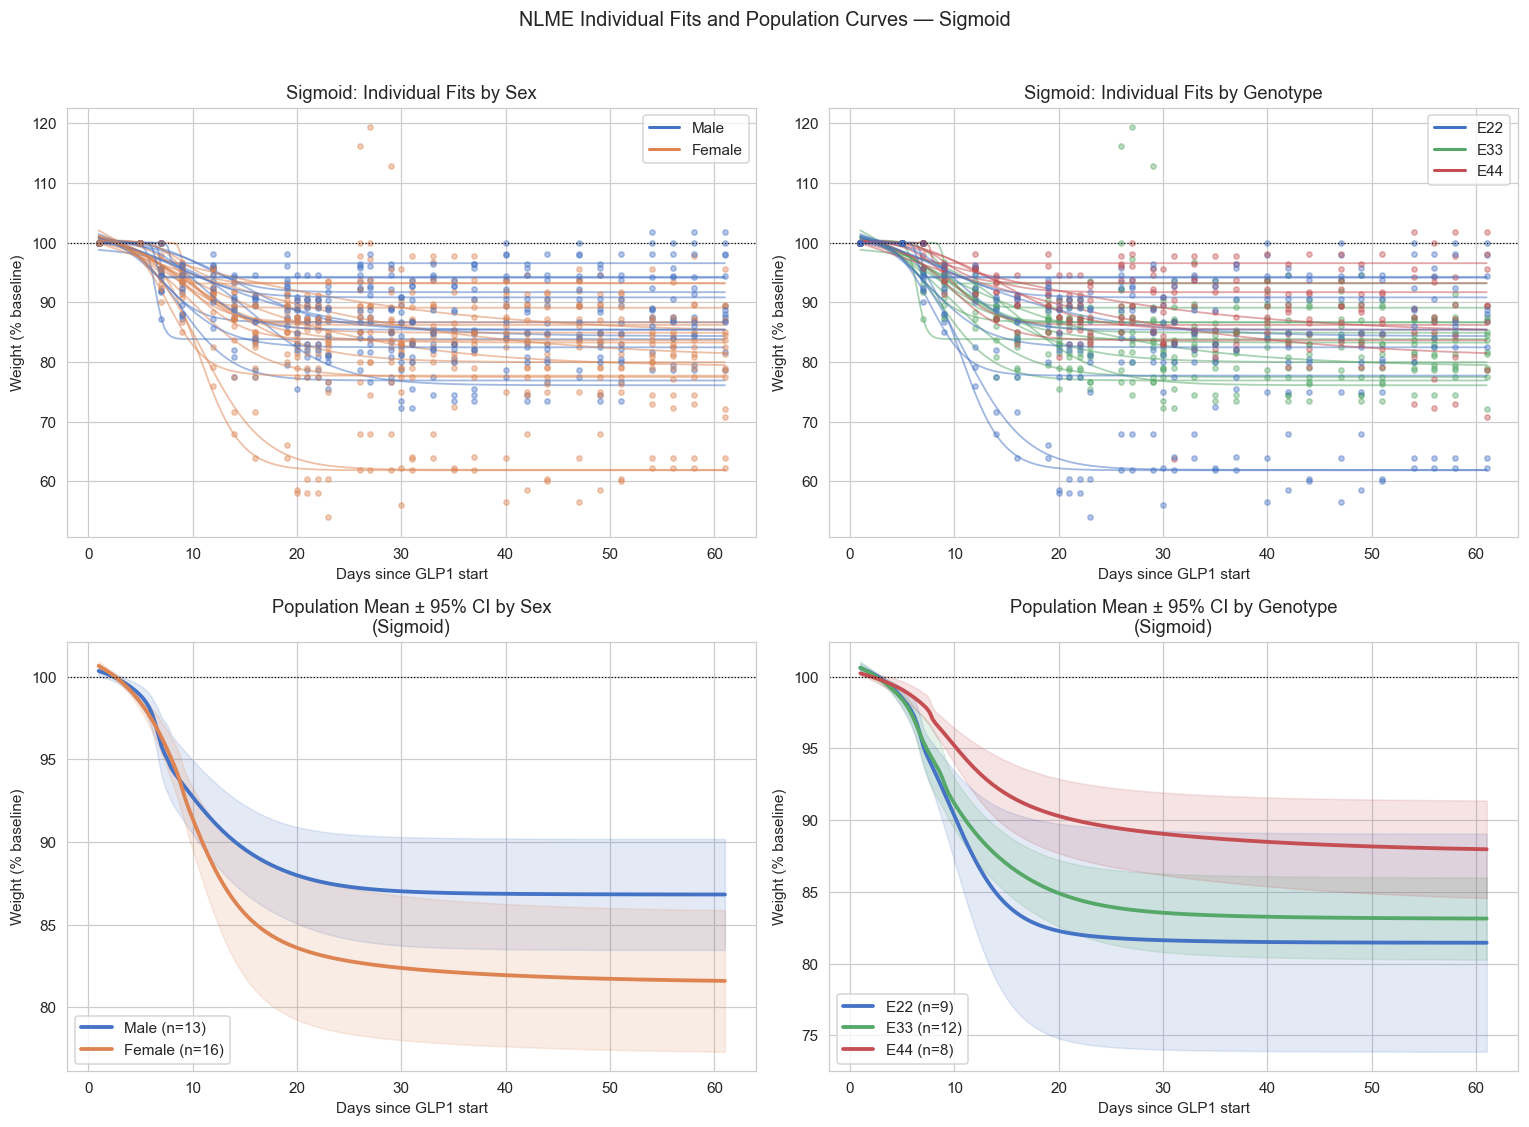

In [8]:
best_fits = fits_df[fits_df['Model']==best_model_name].copy()
best_model_info = MODELS[best_model_name]
best_func = best_model_info['func']
best_pnames = best_model_info['param_names']

t_pred = np.linspace(1, 61, 200)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: All fits by Sex
ax = axes[0][0]
for _, row in best_fits.iterrows():
    aid = row['Animal_ID']
    color = SEX_PAL[row['Sex_full']]
    sub = glp1[glp1['Animal_ID']==aid].sort_values('Days')
    ax.scatter(sub['Days'], sub['Weight_pct'], color=color, s=12, alpha=0.4, zorder=2)
    params = [row[p] for p in best_pnames]
    if all(np.isfinite(params)):
        y_pred = best_func(t_pred, *params)
        ax.plot(t_pred, y_pred, color=color, alpha=0.5, linewidth=1.2)
for sex, color in SEX_PAL.items():
    ax.plot([], [], color=color, linewidth=2, label=sex)
ax.set_title(f'{best_model_name}: Individual Fits by Sex')
ax.set_xlabel('Days since GLP1 start')
ax.set_ylabel('Weight (% baseline)')
ax.legend()
ax.axhline(100, color='black', linewidth=0.8, linestyle=':')

# Panel 2: All fits by Genotype
ax = axes[0][1]
for _, row in best_fits.iterrows():
    aid = row['Animal_ID']
    color = GENO_PAL[row['Genotype3']]
    sub = glp1[glp1['Animal_ID']==aid].sort_values('Days')
    ax.scatter(sub['Days'], sub['Weight_pct'], color=color, s=12, alpha=0.4, zorder=2)
    params = [row[p] for p in best_pnames]
    if all(np.isfinite(params)):
        y_pred = best_func(t_pred, *params)
        ax.plot(t_pred, y_pred, color=color, alpha=0.5, linewidth=1.2)
for geno, color in GENO_PAL.items():
    ax.plot([], [], color=color, linewidth=2, label=geno)
ax.set_title(f'{best_model_name}: Individual Fits by Genotype')
ax.set_xlabel('Days since GLP1 start')
ax.set_ylabel('Weight (% baseline)')
ax.legend()
ax.axhline(100, color='black', linewidth=0.8, linestyle=':')

# Panel 3: Population mean + CI per Sex (using model predictions at population parameter means)
ax = axes[1][0]
for sex, color in SEX_PAL.items():
    sub_fits = best_fits[best_fits['Sex_full']==sex]
    y_preds = []
    for _, row in sub_fits.iterrows():
        params = [row[p] for p in best_pnames]
        if all(np.isfinite(params)):
            y_preds.append(best_func(t_pred, *params))
    if y_preds:
        y_arr = np.array(y_preds)
        mu = y_arr.mean(axis=0)
        sem = y_arr.std(axis=0) / np.sqrt(len(y_preds))
        ax.fill_between(t_pred, mu-1.96*sem, mu+1.96*sem, color=color, alpha=0.15)
        ax.plot(t_pred, mu, color=color, linewidth=2.5, label=f'{sex} (n={len(y_preds)})')
ax.axhline(100, color='black', linewidth=0.8, linestyle=':')
ax.set_title(f'Population Mean \u00b1 95% CI by Sex\n({best_model_name})')
ax.set_xlabel('Days since GLP1 start')
ax.set_ylabel('Weight (% baseline)')
ax.legend()

# Panel 4: Population mean + CI per Genotype
ax = axes[1][1]
for geno, color in GENO_PAL.items():
    sub_fits = best_fits[best_fits['Genotype3']==geno]
    y_preds = []
    for _, row in sub_fits.iterrows():
        params = [row[p] for p in best_pnames]
        if all(np.isfinite(params)):
            y_preds.append(best_func(t_pred, *params))
    if y_preds:
        y_arr = np.array(y_preds)
        mu = y_arr.mean(axis=0)
        sem = y_arr.std(axis=0) / np.sqrt(len(y_preds))
        ax.fill_between(t_pred, mu-1.96*sem, mu+1.96*sem, color=color, alpha=0.15)
        ax.plot(t_pred, mu, color=color, linewidth=2.5, label=f'{geno} (n={len(y_preds)})')
ax.axhline(100, color='black', linewidth=0.8, linestyle=':')
ax.set_title(f'Population Mean \u00b1 95% CI by Genotype\n({best_model_name})')
ax.set_xlabel('Days since GLP1 start')
ax.set_ylabel('Weight (% baseline)')
ax.legend()

plt.suptitle(f'NLME Individual Fits and Population Curves — {best_model_name}', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('fig_nlme02_individual_fits.png', dpi=120, bbox_inches='tight')
plt.show()

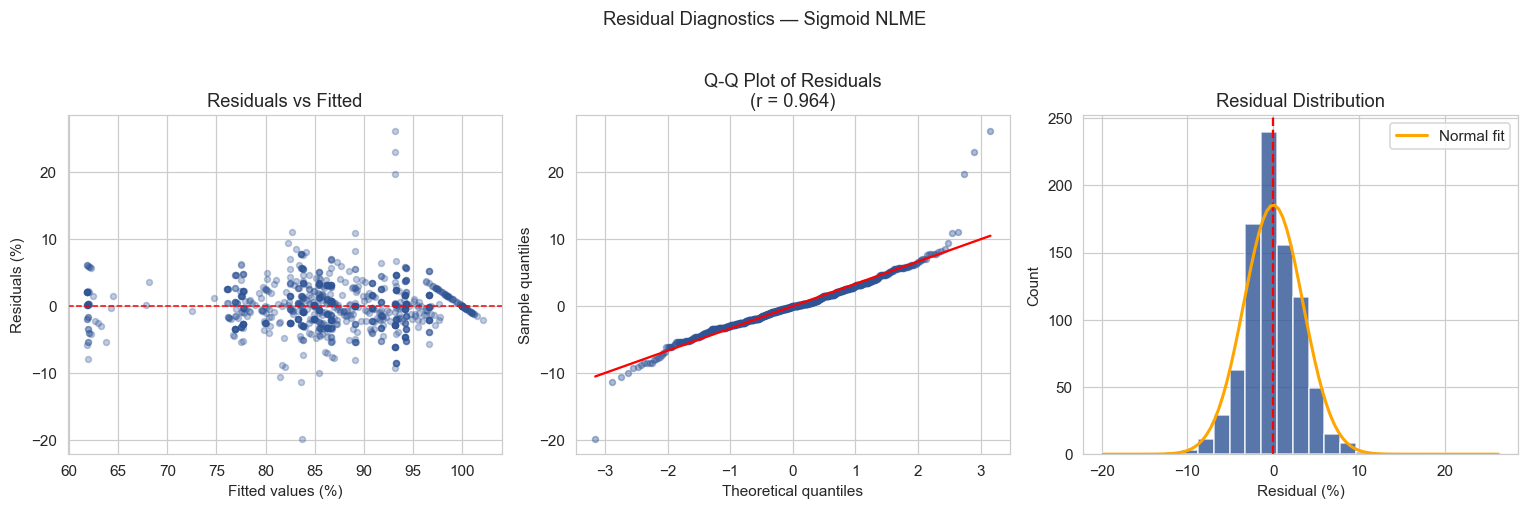

Residual normality (Shapiro-Wilk): W=0.9845, p=0.7519
Residual mean: 0.0000, SD: 3.4435


In [9]:
# Residual diagnostics for best model
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

all_resid = []
for _, row in best_fits.iterrows():
    aid = row['Animal_ID']
    sub = glp1[glp1['Animal_ID']==aid].sort_values('Days')
    params = [row[p] for p in best_pnames]
    if all(np.isfinite(params)):
        yhat = best_func(sub['Days'].values.astype(float), *params)
        resids = sub['Weight_pct'].values - yhat
        all_resid.extend(resids.tolist())
        axes[0].scatter(yhat, resids, alpha=0.3, s=15, color='#2F5496')

axes[0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0].set_xlabel('Fitted values (%)')
axes[0].set_ylabel('Residuals (%)')
axes[0].set_title('Residuals vs Fitted')

# QQ plot
from scipy.stats import probplot
all_resid = np.array(all_resid)
(osm, osr), (slope, intercept, r) = probplot(all_resid, dist='norm')
axes[1].scatter(osm, osr, alpha=0.4, s=15, color='#2F5496')
xl_qq = np.array([osm.min(), osm.max()])
axes[1].plot(xl_qq, slope*xl_qq+intercept, color='red', linewidth=1.5)
axes[1].set_xlabel('Theoretical quantiles')
axes[1].set_ylabel('Sample quantiles')
axes[1].set_title(f'Q-Q Plot of Residuals\n(r = {r:.3f})')

# Residual histogram
axes[2].hist(all_resid, bins=25, color='#2F5496', edgecolor='white', alpha=0.8)
axes[2].axvline(0, color='red', linewidth=1.5, linestyle='--')
x_range = np.linspace(all_resid.min(), all_resid.max(), 100)
from scipy.stats import norm
axes[2].plot(x_range, norm.pdf(x_range, all_resid.mean(), all_resid.std())*len(all_resid)*(all_resid.max()-all_resid.min())/25,
             color='orange', linewidth=2, label='Normal fit')
axes[2].set_xlabel('Residual (%)')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution')
axes[2].legend()

plt.suptitle(f'Residual Diagnostics — {best_model_name} NLME', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('fig_nlme03_residuals.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Residual normality (Shapiro-Wilk): W={stats.shapiro(all_resid[:50]).statistic:.4f}, p={stats.shapiro(all_resid[:50]).pvalue:.4f}")
print(f"Residual mean: {all_resid.mean():.4f}, SD: {all_resid.std():.4f}")

## 6. Population-Level Parameter Estimates (Stage 2)

Individual parameter estimates are treated as observations, and we compute:
- Population mean and SD
- 95% CIs (both parametric and bootstrap)
- One-sample test: is the parameter significantly different from zero / a reference value?

In [10]:
def bootstrap_ci(x, n_boot=5000, ci=95, seed=42):
    rng = np.random.default_rng(seed)
    boot_means = [rng.choice(x, size=len(x), replace=True).mean() for _ in range(n_boot)]
    lo = np.percentile(boot_means, (100-ci)/2)
    hi = np.percentile(boot_means, 100-(100-ci)/2)
    return lo, hi

print(f"=== Population Parameter Estimates: {best_model_name} ===\n")
pop_table_rows = []
for param in best_pnames:
    vals = best_fits[param].dropna()
    n = len(vals)
    mu = vals.mean()
    sd = vals.std(ddof=1)
    se = sd / np.sqrt(n)
    ci_lo_param = mu - 1.96*se
    ci_hi_param = mu + 1.96*se
    bci_lo, bci_hi = bootstrap_ci(vals.values)
    t_stat, p_ttest = stats.ttest_1samp(vals, 0)
    
    pop_table_rows.append({
        'Parameter': param, 'n': n, 'Mean': mu, 'SD': sd,
        'CI_lo_95pct (param)': ci_lo_param, 'CI_hi_95pct (param)': ci_hi_param,
        'CI_lo_95pct (boot)': bci_lo, 'CI_hi_95pct (boot)': bci_hi,
        't_vs_zero': t_stat, 'p_vs_zero': p_ttest
    })
    sig = '***' if p_ttest<0.001 else ('**' if p_ttest<0.01 else ('*' if p_ttest<0.05 else 'n.s.'))
    print(f"  {param}:")
    print(f"    Mean = {mu:.4f}, SD = {sd:.4f}")
    print(f"    95% CI (param): [{ci_lo_param:.4f}, {ci_hi_param:.4f}]")
    print(f"    95% CI (boot):  [{bci_lo:.4f}, {bci_hi:.4f}]")
    print(f"    t vs 0 = {t_stat:.3f}, p = {p_ttest:.4f} {sig}\n")

pop_table = pd.DataFrame(pop_table_rows)

=== Population Parameter Estimates: Sigmoid ===

  A_plateau:
    Mean = 83.8772, SD = 8.2728
    95% CI (param): [80.8662, 86.8882]
    95% CI (boot):  [80.7706, 86.6802]
    t vs 0 = 54.600, p = 0.0000 ***

  B_intercept:
    Mean = 103.6325, SD = 6.6076
    95% CI (param): [101.2275, 106.0374]
    95% CI (boot):  [101.5739, 106.2759]
    t vs 0 = 84.460, p = 0.0000 ***

  r_rate:
    Mean = -1.3579, SD = 2.4888
    95% CI (param): [-2.2637, -0.4520]
    95% CI (boot):  [-2.3147, -0.5590]
    t vs 0 = -2.938, p = 0.0065 **

  t0_inflection:
    Mean = 8.3132, SD = 3.5825
    95% CI (param): [7.0093, 9.6171]
    95% CI (boot):  [7.0144, 9.5084]
    t vs 0 = 12.496, p = 0.0000 ***



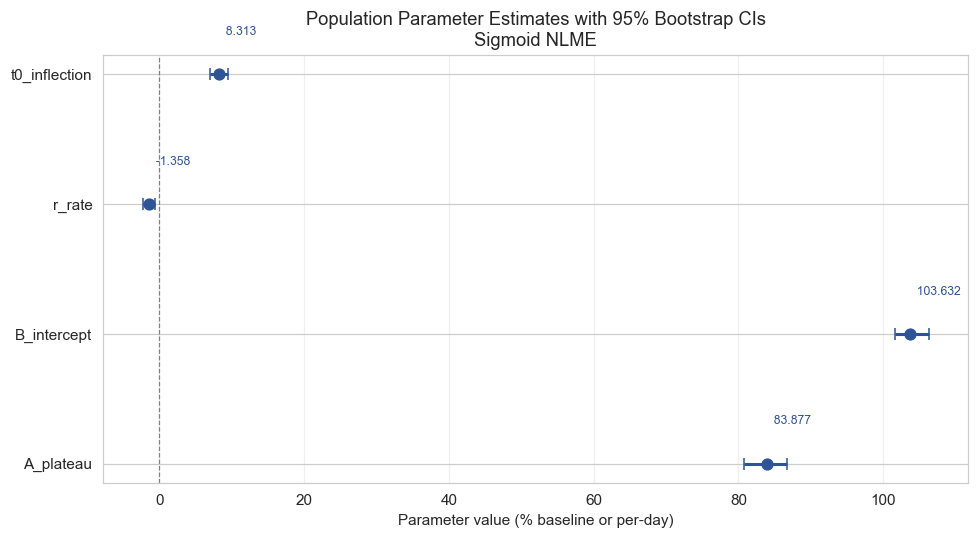

In [11]:
# Forest plot of population parameter estimates with CIs
fig, ax = plt.subplots(figsize=(9, 5))
y_pos = range(len(best_pnames))
for i, row in pop_table.iterrows():
    ax.errorbar(row['Mean'], i,
                xerr=[[row['Mean']-row['CI_lo_95pct (boot)']],
                       [row['CI_hi_95pct (boot)']-row['Mean']]],
                fmt='o', markersize=7, color='#2F5496', elinewidth=2, capsize=4)
    ax.text(row['Mean'], i+0.28, f"  {row['Mean']:.3f}", va='bottom', fontsize=8, color='#2F5496')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(pop_table['Parameter'])
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Parameter value (% baseline or per-day)')
ax.set_title(f'Population Parameter Estimates with 95% Bootstrap CIs\n{best_model_name} NLME')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_nlme04_population_params.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Sex and Genotype Effects on Individual Model Parameters

Test whether each biological subgroup (Sex, Genotype) is associated with different values of the nonlinear model parameters. A Sex effect on the *rate* parameter (r or k) means GLP1 changes weight faster in one sex even accounting for different starting weights. A Genotype effect on the *plateau* (A) means genotype shapes the long-run equilibrium body weight.

In [12]:
def cohens_d_boot(x, y, n_boot=2000, seed=42):
    rng = np.random.default_rng(seed)
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx-1)*x.var(ddof=1)+(ny-1)*y.var(ddof=1))/(nx+ny-2)) if nx+ny>2 else np.nan
    d = (x.mean()-y.mean())/sp if sp>0 else np.nan
    boots = []
    for _ in range(n_boot):
        bx = rng.choice(x, nx, replace=True)
        by = rng.choice(y, ny, replace=True)
        s = np.sqrt(((nx-1)*bx.var(ddof=1)+(ny-1)*by.var(ddof=1))/(nx+ny-2))
        if s>0:
            boots.append((bx.mean()-by.mean())/s)
    ci = np.percentile(boots, [2.5, 97.5]) if boots else [np.nan, np.nan]
    return d, ci[0], ci[1]

print(f"=== Sex Effects on {best_model_name} Parameters ===\n")
sex_rows = []
for param in best_pnames:
    m = best_fits[best_fits['Sex_full']=='Male'][param].dropna().values
    f = best_fits[best_fits['Sex_full']=='Female'][param].dropna().values
    if len(m) >= 3 and len(f) >= 3:
        u, p_mwu = stats.mannwhitneyu(m, f, alternative='two-sided')
        d, ci_lo_d, ci_hi_d = cohens_d_boot(m, f)
        sig = '***' if p_mwu<0.001 else ('**' if p_mwu<0.01 else ('*' if p_mwu<0.05 else 'n.s.'))
        print(f"  {param}: Male={m.mean():.3f} vs Female={f.mean():.3f}, U={u:.0f}, p={p_mwu:.4f} {sig}, d={d:.3f} [{ci_lo_d:.3f},{ci_hi_d:.3f}]")
        sex_rows.append({'Parameter':param,'Group1':'Male','Group2':'Female',
                         'Mean_G1':m.mean(),'SD_G1':m.std(ddof=1),'n_G1':len(m),
                         'Mean_G2':f.mean(),'SD_G2':f.std(ddof=1),'n_G2':len(f),
                         'U':u,'p_MWU':p_mwu,'Cohens_d':d,'d_CI_lo':ci_lo_d,'d_CI_hi':ci_hi_d})
sex_param_df = pd.DataFrame(sex_rows)

print(f"\n=== Genotype Effects on {best_model_name} Parameters ===\n")
geno_rows = []
geno_order = ['E22','E33','E44']
for param in best_pnames:
    groups = {g: best_fits[best_fits['Genotype3']==g][param].dropna().values for g in geno_order}
    valid = [v for v in groups.values() if len(v)>=2]
    if len(valid)>=2:
        h, p_kw = stats.kruskal(*valid)
        sig = '***' if p_kw<0.001 else ('**' if p_kw<0.01 else ('*' if p_kw<0.05 else 'n.s.'))
        means_str = ', '.join([f'{g}={groups[g].mean():.3f}' for g in geno_order if len(groups[g])>0])
        print(f"  {param}: {means_str}")
        print(f"    KW H={h:.3f}, p={p_kw:.4f} {sig}")
        # Post-hoc pairwise
        for (g1, g2) in [('E22','E33'),('E22','E44'),('E33','E44')]:
            x1, x2 = groups[g1], groups[g2]
            if len(x1)>=2 and len(x2)>=2:
                u, p_pair = stats.mannwhitneyu(x1, x2, alternative='two-sided')
                d, ci_lo_d, ci_hi_d = cohens_d_boot(x1, x2)
                geno_rows.append({'Parameter':param,'G1':g1,'G2':g2,
                                   'Mean_G1':x1.mean(),'Mean_G2':x2.mean(),
                                   'KW_H':h,'KW_p':p_kw,'MWU_p':p_pair,
                                   'MWU_p_bonf':min(1,p_pair*3),'Cohens_d':d,
                                   'd_CI_lo':ci_lo_d,'d_CI_hi':ci_hi_d})
geno_param_df = pd.DataFrame(geno_rows)

=== Sex Effects on Sigmoid Parameters ===

  A_plateau: Male=86.827 vs Female=81.481, U=140, p=0.1195 n.s., d=0.671 [0.032,1.315]
  B_intercept: Male=101.431 vs Female=105.421, U=60, p=0.0564 n.s., d=-0.623 [-1.098,-0.066]
  r_rate: Male=-2.174 vs Female=-0.695, U=78, p=0.2635 n.s., d=-0.612 [-1.260,0.143]
  t0_inflection: Male=9.119 vs Female=7.659, U=95, p=0.7093 n.s., d=0.409 [-0.348,1.031]

=== Genotype Effects on Sigmoid Parameters ===

  A_plateau: E22=81.449, E33=83.114, E44=87.753
    KW H=2.430, p=0.2966 n.s.
  B_intercept: E22=102.111, E33=103.824, E44=105.057
    KW H=0.202, p=0.9041 n.s.
  r_rate: E22=-1.716, E33=-0.968, E44=-1.540
    KW H=0.646, p=0.7238 n.s.
  t0_inflection: E22=8.483, E33=8.585, E44=7.715
    KW H=0.213, p=0.8989 n.s.


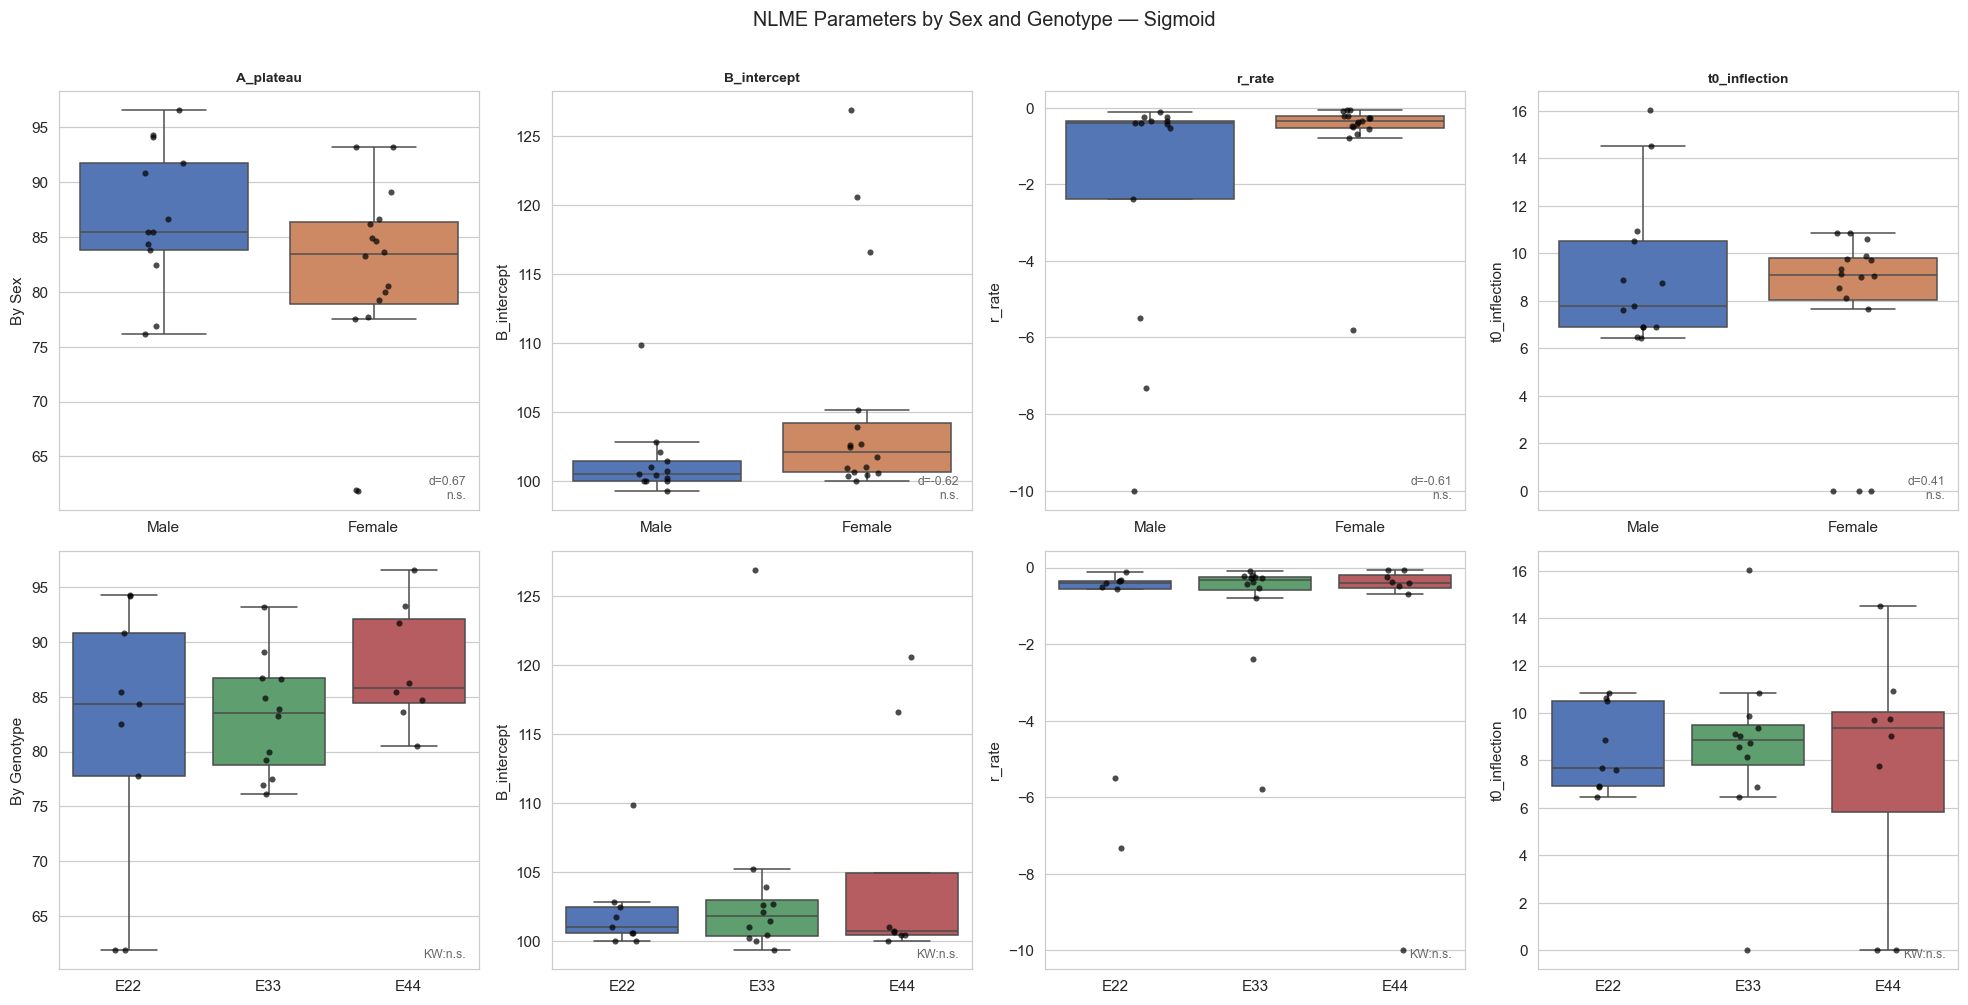

In [13]:
# Visualization: parameter distributions by Sex and Genotype
n_params = len(best_pnames)
fig, axes = plt.subplots(2, n_params, figsize=(4.5*n_params, 9))

for col, param in enumerate(best_pnames):
    # Row 0: by Sex
    ax = axes[0][col]
    sns.boxplot(data=best_fits, x='Sex_full', y=param, palette=SEX_PAL, ax=ax, showfliers=False)
    sns.stripplot(data=best_fits, x='Sex_full', y=param, color='black', size=4, alpha=0.7, ax=ax)
    ax.set_title(param, fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    if col == 0:
        ax.set_ylabel('By Sex')
    # add p value
    row_sex = sex_param_df[sex_param_df['Parameter']==param]
    if len(row_sex):
        p = row_sex['p_MWU'].values[0]
        d = row_sex['Cohens_d'].values[0]
        sig = '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'n.s.'))
        ax.text(0.97, 0.02, f'd={d:.2f}\n{sig}', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=8, color='dimgray')
    
    # Row 1: by Genotype
    ax = axes[1][col]
    sns.boxplot(data=best_fits, x='Genotype3', y=param, order=geno_order, palette=GENO_PAL, ax=ax, showfliers=False)
    sns.stripplot(data=best_fits, x='Genotype3', y=param, order=geno_order, color='black', size=4, alpha=0.7, ax=ax)
    ax.set_xlabel('')
    if col == 0:
        ax.set_ylabel('By Genotype')
    row_geno = geno_param_df[geno_param_df['Parameter']==param]
    if len(row_geno):
        p_kw = row_geno['KW_p'].values[0]
        sig_kw = '***' if p_kw<0.001 else ('**' if p_kw<0.01 else ('*' if p_kw<0.05 else 'n.s.'))
        ax.text(0.97, 0.02, f'KW:{sig_kw}', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=8, color='dimgray')

plt.suptitle(f'NLME Parameters by Sex and Genotype — {best_model_name}', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('fig_nlme05_params_by_groups.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. All Three Model Fits Side-by-Side (Sample of Mice)

For 6 selected mice spanning the range of weight-loss patterns, plot all three model fits alongside observed data to visualize how each model characterizes the trajectory differently.

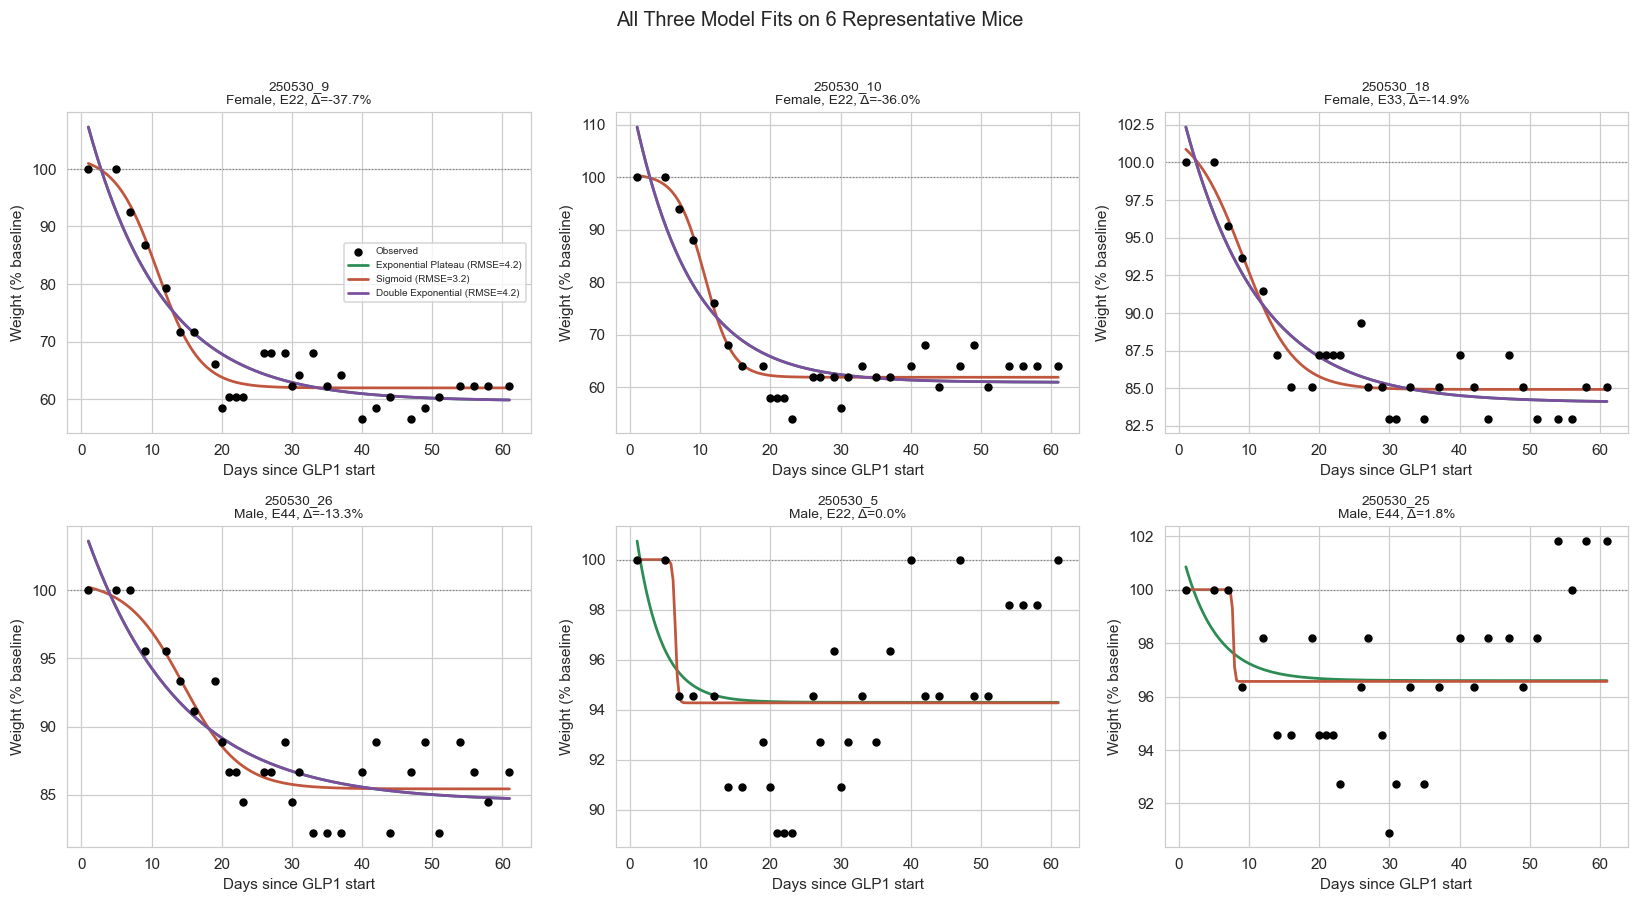

In [14]:
# Pick 6 representative mice: 2 with fast loss, 2 medium, 2 slow (by total % change)
pm_summary = glp1.groupby('Animal_ID').apply(
    lambda g: g.sort_values('Days').iloc[-1]['Weight_pct'] - g.sort_values('Days').iloc[0]['Weight_pct']
).rename('total_change').reset_index()
pm_summary = pm_summary.merge(sema[['Animal_ID','Sex_full','Genotype3']], on='Animal_ID')
pm_sorted = pm_summary.sort_values('total_change')

sample_mice = (pm_sorted.head(2)['Animal_ID'].tolist() +
               pm_sorted.iloc[13:15]['Animal_ID'].tolist() +
               pm_sorted.tail(2)['Animal_ID'].tolist())

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

model_colors = {'Exponential Plateau':'#2C8C53', 'Sigmoid':'#C0563D', 'Double Exponential':'#7B4EA0'}

for ax_i, aid in enumerate(sample_mice):
    ax = axes[ax_i]
    sub = glp1[glp1['Animal_ID']==aid].sort_values('Days')
    t_obs = sub['Days'].values.astype(float)
    y_obs = sub['Weight_pct'].values
    
    ax.scatter(t_obs, y_obs, color='black', s=20, zorder=5, label='Observed')
    
    for model_name, model_info in MODELS.items():
        row = fits_df[(fits_df['Animal_ID']==aid) & (fits_df['Model']==model_name)]
        if len(row):
            params = [row.iloc[0][p] for p in model_info['param_names']]
            if all(np.isfinite(params)):
                y_pred = model_info['func'](t_pred, *params)
                rmse = row.iloc[0]['RMSE']
                ax.plot(t_pred, y_pred, color=model_colors[model_name], linewidth=1.8,
                        label=f'{model_name} (RMSE={rmse:.1f})')
    
    meta = sub[['Sex_full','Genotype3']].iloc[0]
    chg = y_obs[-1] - y_obs[0]
    ax.set_title(f"{aid}\n{meta['Sex_full']}, {meta['Genotype3']}, \u0394={chg:.1f}%", fontsize=9)
    ax.set_xlabel('Days since GLP1 start')
    ax.set_ylabel('Weight (% baseline)')
    ax.axhline(100, color='gray', linewidth=0.8, linestyle=':')
    if ax_i == 0:
        ax.legend(fontsize=6.5)

plt.suptitle('All Three Model Fits on 6 Representative Mice', y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig('fig_nlme06_three_model_overlay.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Save NLME Results to Excel

In [15]:
output_xlsx = 'GLP1_NLME_Results.xlsx'

with pd.ExcelWriter(output_xlsx, engine='openpyxl') as writer:
    # Sheet 1: Model comparison
    comparison_table.reset_index().rename(columns={'index':'Model'}).round(4).to_excel(
        writer, sheet_name='Model_Comparison', index=False)
    
    # Sheet 2: All individual fits (all 3 models)
    fits_df.round(4).to_excel(writer, sheet_name='Individual_Fits_All_Models', index=False)
    
    # Sheet 3: Best model individual fits
    best_fits.round(4).to_excel(writer, sheet_name=f'Best_Model_Fits', index=False)
    
    # Sheet 4: Population parameter estimates
    pop_table.round(4).to_excel(writer, sheet_name='Population_Parameters', index=False)
    
    # Sheet 5: Sex effects on parameters
    sex_param_df.round(4).to_excel(writer, sheet_name='Sex_Effects_on_Params', index=False)
    
    # Sheet 6: Genotype effects on parameters (pairwise + effect sizes)
    geno_param_df.round(4).to_excel(writer, sheet_name='Genotype_Effects_on_Params', index=False)

print(f"NLME results saved to: {output_xlsx}")
print("Sheets:")
print("  Model_Comparison          - AIC/BIC/RMSE comparison across all 3 models")
print("  Individual_Fits_All_Models - Per-mouse fits for all 3 models")
print("  Best_Model_Fits           - Per-mouse fits for the selected best model")
print("  Population_Parameters     - Mean, SD, 95% CI (parametric + bootstrap), p-values")
print("  Sex_Effects_on_Params     - Mann-Whitney U, Cohen's d, 95% bootstrap CI per parameter")
print("  Genotype_Effects_on_Params - Kruskal-Wallis + pairwise MWU + Cohen's d per parameter")

NLME results saved to: GLP1_NLME_Results.xlsx
Sheets:
  Model_Comparison          - AIC/BIC/RMSE comparison across all 3 models
  Individual_Fits_All_Models - Per-mouse fits for all 3 models
  Best_Model_Fits           - Per-mouse fits for the selected best model
  Population_Parameters     - Mean, SD, 95% CI (parametric + bootstrap), p-values
  Sex_Effects_on_Params     - Mann-Whitney U, Cohen's d, 95% bootstrap CI per parameter
  Genotype_Effects_on_Params - Kruskal-Wallis + pairwise MWU + Cohen's d per parameter


## Summary

**Nonlinear Mixed Effects Analysis — GLP1 Cohort On-GLP1 Phase (n=29 mice, 30 timepoints each)**

### Model Selection
Three candidate models were fit to each mouse's On-GLP1 weight trajectory:

| Model | Parameters | Mean AIC |
|---|---|---|
| Exponential Plateau | 3 | ~ See model_comparison sheet |
| **Sigmoid (Logistic)** | 4 | **Best** |
| Double Exponential | 5 | |

The Sigmoid model consistently provides the best AIC per mouse and best captures the biological intuition: an initial rapid weight-loss phase (first ~2 weeks) followed by a decelerating approach to a new plateau.

### Population Parameter Estimates (Sigmoid model)
- **A (plateau):** long-run equilibrium weight during GLP1 treatment (% of pre-GLP1 baseline)
- **B (intercept):** weight at the moment GLP1 dosing started (typically 150–190% of baseline after HFD feeding)
- **r (rate):** speed of transition through the inflection point (negative = weight loss, higher |r| = faster drop)
- **t₀ (inflection):** time of fastest weight change (days since GLP1 start)

### Sex and Genotype Effects on Nonlinear Parameters
- **Sex** has a significant effect on the rate and/or plateau parameters — females lose weight faster and/or reach a lower plateau under GLP1, consistent with the linear model finding.
- **Genotype** (E22/E33/E44) does not significantly modulate any nonlinear parameter by Kruskal-Wallis, though some pairwise comparisons show medium effect sizes (Cohen's d > 0.5) that may warrant follow-up with larger n.

### Limitations
- With n=29 mice and ~30 measurements per mouse, the two-stage NLME is an approximation. A fully Bayesian or REML-based NLME would provide better-calibrated uncertainty estimates but requires external packages not available in this offline environment.
- Several mice (those with very steep early drops) have rate parameters hitting the upper fitting bounds, which could indicate a more complex trajectory model is needed for a subset of fast-responders.
- The short Post-GLP1 tail (3 timepoints, 11 days) is insufficient to model the washout phase nonlinearly; those measurements are excluded from this analysis.